In [1]:
import os
import re
import numpy as np
import pandas as pd
import rasterio
from rasterstats import zonal_stats

def decode_cloud_confidence(array):
    return array & 0b11  # Extract bits 0–1

# Replace this section with actual ntl_files, cloud_files, counties_gdf, and output_csv
results = []
for ntl_path, cloud_path in zip(ntl_files, cloud_files):
    filename = os.path.basename(ntl_path)
    match = re.search(r"(\d{4})(\d{3})", filename)
    if match:
        year, julian_day = match.groups()
        date_str = pd.to_datetime(f"{year}-{julian_day}", format="%Y-%j").strftime("%Y-%m-%d")
    else:
        date_str = "Unknown"

    ntl_stats = zonal_stats(counties_gdf, ntl_path, stats=["mean", "median", "count"])
    with rasterio.open(cloud_path) as src:
        qf_array = src.read(1)
        decoded_array = decode_cloud_confidence(qf_array)
        profile = src.profile
        profile.update(dtype=rasterio.uint8, count=1)
        tmp_path = "temp_decoded_cloud.tif"
        with rasterio.open(tmp_path, "w", **profile) as dst:
            dst.write(decoded_array.astype(rasterio.uint8), 1)

    cloud_stats = zonal_stats(counties_gdf, tmp_path, categorical=True)
    for idx, (ntl_zone, cloud_zone) in enumerate(zip(ntl_stats, cloud_stats)):
        if ntl_zone.get("count") is None or ntl_zone.get("count") == 0:
            continue
        county_name = counties_gdf.loc[idx, "CNTY_NM"]
        mean_ntl = round(ntl_zone.get("mean", 0), 2)
        median_ntl = round(ntl_zone.get("median", 0), 2)
        total_pixels = int(ntl_zone.get("count", 0))
        class_map = {
            0: "Confident Clear",
            1: "Probably Clear",
            2: "Probably Cloudy",
            3: "Confident Cloudy"
        }
        class_counts = {class_map.get(k, f"Class {k}"): v for k, v in cloud_zone.items()}
        count_conf_clear   = class_counts.get("Confident Clear", 0)
        count_prob_clear   = class_counts.get("Probably Clear", 0)
        count_prob_cloudy  = class_counts.get("Probably Cloudy", 0)
        count_conf_cloudy  = class_counts.get("Confident Cloudy", 0)
        total_cloud_pixels = sum([count_conf_clear, count_prob_clear, count_prob_cloudy, count_conf_cloudy])
        if total_cloud_pixels > 0:
            conf_clear_pct  = round((count_conf_clear / total_cloud_pixels) * 100, 2)
            prob_clear_pct  = round((count_prob_clear / total_cloud_pixels) * 100, 2)
            prob_cloudy_pct = round((count_prob_cloudy / total_cloud_pixels) * 100, 2)
            conf_cloudy_pct = round((count_conf_cloudy / total_cloud_pixels) * 100, 2)
        else:
            conf_clear_pct = prob_clear_pct = prob_cloudy_pct = conf_cloudy_pct = 0.0
        results.append({
            "County": county_name,
            "Date": date_str,
            "Mean_NTL": mean_ntl,
            "Median_NTL": median_ntl,
            "Total_Pixels": total_pixels,
            "Confident_Clear_%": conf_clear_pct,
            "Probably_Clear_%": prob_clear_pct,
            "Probably_Cloudy_%": prob_cloudy_pct,
            "Confident_Cloudy_%": conf_cloudy_pct
        })
df_results = pd.DataFrame(results)
df_results = df_results.groupby(["County", "Date"], as_index=False).mean()
df_results.to_csv(output_csv, index=False)
print(f"✅ CSV successfully saved to: {output_csv}")
df_results.head()


In [2]:
import os
import re
import numpy as np
import pandas as pd
import rasterio
from rasterstats import zonal_stats

def decode_cloud_confidence(array):
    return array & 0b11  # Extract bits 0–1

# Replace this section with actual ntl_files, cloud_files, counties_gdf, and output_csv
results = []
for ntl_path, cloud_path in zip(ntl_files, cloud_files):
    filename = os.path.basename(ntl_path)
    match = re.search(r"(\d{4})(\d{3})", filename)
    if match:
        year, julian_day = match.groups()
        date_str = pd.to_datetime(f"{year}-{julian_day}", format="%Y-%j").strftime("%Y-%m-%d")
    else:
        date_str = "Unknown"

    ntl_stats = zonal_stats(counties_gdf, ntl_path, stats=["mean", "median", "count"])
    with rasterio.open(cloud_path) as src:
        qf_array = src.read(1)
        decoded_array = decode_cloud_confidence(qf_array)
        profile = src.profile
        profile.update(dtype=rasterio.uint8, count=1)
        tmp_path = "temp_decoded_cloud.tif"
        with rasterio.open(tmp_path, "w", **profile) as dst:
            dst.write(decoded_array.astype(rasterio.uint8), 1)

    cloud_stats = zonal_stats(counties_gdf, tmp_path, categorical=True)
    for idx, (ntl_zone, cloud_zone) in enumerate(zip(ntl_stats, cloud_stats)):
        if ntl_zone.get("count") is None or ntl_zone.get("count") == 0:
            continue
        county_name = counties_gdf.loc[idx, "CNTY_NM"]
        mean_ntl = round(ntl_zone.get("mean", 0), 2)
        median_ntl = round(ntl_zone.get("median", 0), 2)
        total_pixels = int(ntl_zone.get("count", 0))
        class_map = {
            0: "Confident Clear",
            1: "Probably Clear",
            2: "Probably Cloudy",
            3: "Confident Cloudy"
        }
        class_counts = {class_map.get(k, f"Class {k}"): v for k, v in cloud_zone.items()}
        count_conf_clear   = class_counts.get("Confident Clear", 0)
        count_prob_clear   = class_counts.get("Probably Clear", 0)
        count_prob_cloudy  = class_counts.get("Probably Cloudy", 0)
        count_conf_cloudy  = class_counts.get("Confident Cloudy", 0)
        total_cloud_pixels = sum([count_conf_clear, count_prob_clear, count_prob_cloudy, count_conf_cloudy])
        if total_cloud_pixels > 0:
            conf_clear_pct  = round((count_conf_clear / total_cloud_pixels) * 100, 2)
            prob_clear_pct  = round((count_prob_clear / total_cloud_pixels) * 100, 2)
            prob_cloudy_pct = round((count_prob_cloudy / total_cloud_pixels) * 100, 2)
            conf_cloudy_pct = round((count_conf_cloudy / total_cloud_pixels) * 100, 2)
        else:
            conf_clear_pct = prob_clear_pct = prob_cloudy_pct = conf_cloudy_pct = 0.0
        results.append({
            "County": county_name,
            "Date": date_str,
            "Mean_NTL": mean_ntl,
            "Median_NTL": median_ntl,
            "Total_Pixels": total_pixels,
            "Confident_Clear_%": conf_clear_pct,
            "Probably_Clear_%": prob_clear_pct,
            "Probably_Cloudy_%": prob_cloudy_pct,
            "Confident_Cloudy_%": conf_cloudy_pct
        })
df_results = pd.DataFrame(results)
df_results = df_results.groupby(["County", "Date"], as_index=False).mean()
df_results.to_csv(output_csv, index=False)
print(f"✅ CSV successfully saved to: {output_csv}")
df_results.head()


✅ Overlap-corrected CSV saved to: /Users/ba924/Downloads/NASA/Work/TX_NTL_Statistics.csv


,County,Date,Mean_NTL,Median_NTL,Total_Pixels,Confident_Clear_%,Probably_Clear_%,Probably_Cloudy_%,Confident_Cloudy_%
0,Anderson,2024-04-30,9.78,4.0,11313.0,100.00,0.00,0.00,0.00
1,Anderson,2024-05-15,13.13,7.0,15096.0,55.37,15.49,26.25,2.89
2,Anderson,2024-05-16,3.91,3.0,34.0,85.71,14.29,0.00,0.00
3,Anderson,2024-05-17,8.34,4.0,15326.0,66.61,29.26,4.11,0.02
4,Anderson,2024-05-18,8.46,4.0,8560.0,37.56,34.54,19.74,8.16


For creating Graphs of NTL and Confidence Clear %

In [9]:
# Import necessary libraries
import os  
# Import necessary libraries
import pandas as pd
# Import necessary libraries
import matplotlib.pyplot as plt
# Import necessary libraries
import seaborn as sns

# Define output directory
output_graphs_folder = "Downloads/NASA/TX_PPT"
os.makedirs(output_graphs_folder, exist_ok=True)

# Load dataset
csv_path = "Downloads/NASA/Work/TX_NTL_Statistics.csv"
df = pd.read_csv(csv_path)

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Rename columns
df.rename(columns={"County": "NAME"}, inplace=True)

# ✅ Step 1: Convert Date column to datetime format
# Convert the extracted year and Julian day into a standard date format
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# ✅ Step 2: Ensure all counties have "Pre-Event (2021-11-29)"
all_counties = df["NAME"].unique()
missing_pre_event = all_counties[~df[df["Date"] == pd.Timestamp("2021-11-29")]["NAME"].isin(all_counties)]
for county in missing_pre_event:
# Convert the list of results into a DataFrame
    df = pd.concat([df, pd.DataFrame({"NAME": [county], "Date": [pd.Timestamp("2021-11-29")], 
                                      "Mean_NTL": [None], "Median_NTL": [None], "Confident_Clear_%": [None]})])

# Convert Date column back to datetime for correct sorting
# Convert the extracted year and Julian day into a standard date format
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# ✅ Step 3: Sort dates chronologically for each county
df = df.sort_values(by=["NAME", "Date"])

# ✅ Step 4: Convert Date column back to string for proper formatting (YYYY-MM-DD only)
df["Date"] = df["Date"].dt.strftime("%Y-%m-%d")

# Set fixed Y-axis limits
max_ntl = 50  
max_clear = 100  

# Improve plot readability
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 14, 
    'axes.labelsize': 16, 
    'axes.titlesize': 18, 
    'legend.fontsize': 14,
    'axes.titleweight': 'bold',  
    'axes.labelweight': 'bold',  
    'xtick.labelsize': 12,  
    'ytick.labelsize': 14,
    'axes.grid': True,
    'grid.alpha': 0.6,
    'grid.linestyle': '--'
})

# ✅ Generate time-series graphs per county
for county in df["NAME"].unique():
    county_df = df[df["NAME"] == county].copy()

    # Convert Date column to categorical type with correct order
    county_df["Date"] = pd.Categorical(county_df["Date"], ordered=True, categories=sorted(county_df["Date"].unique()))

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Set consistent Y-axis limits
    ax1.set_ylim(0, max_ntl)  

    # Plot NTL values
    lns1 = ax1.plot(county_df["Date"], county_df["Mean_NTL"], marker='o', linestyle='-', 
                     label="Mean NTL", color='blue', markersize=6, linewidth=2)
    lns2 = ax1.plot(county_df["Date"], county_df["Median_NTL"], marker='s', linestyle='--', 
                     label="Median NTL", color='green', markersize=6, linewidth=2)
    ax1.set_ylabel("NTL Value", fontsize=16, fontweight='bold')
    ax1.tick_params(axis='y', labelsize=14)

    # Create twin axis for Confident Clear %
    ax2 = ax1.twinx()
    lns3 = ax2.plot(county_df["Date"], county_df["Confident_Clear_%"], marker='^', linestyle='--', 
                     label="Confident Clear %", color='red', markersize=6, linewidth=2)
    ax2.set_ylabel("Confident Clear (%)", fontsize=16, fontweight='bold')

    # Set fixed Y-axis limits for Confident Clear %
    ax2.set_ylim(0, max_clear)
    ax2.tick_params(axis='y', labelsize=14)

    # ✅ Step 5: Fix X-axis labels (Ensure even spacing and remove time)
    ax1.set_xticks(range(len(county_df["Date"])))
    ax1.set_xticklabels(county_df["Date"], rotation=25, ha="right")

    # Make Legend Transparent
    #lns = lns1 + lns2 + lns3
    #labels = [l.get_label() for l in lns]
    #legend = ax1.legend(lns, labels, loc="upper left", fontsize=14, frameon=True, fancybox=True, 
    #                    framealpha=0.5, shadow=False, borderpad=1)  

    # Title
    ax1.set_title(f"NTL Time-Series for {county}", fontsize=18, fontweight='bold')

    # Save Graph
    graph_path = os.path.join(output_graphs_folder, f"{county}_NTL_Timeseries_Publication.png")
    plt.savefig(graph_path, bbox_inches="tight", dpi=300)  
    plt.close()

print(f"✅ Publication-ready graphs saved in: {output_graphs_folder}")

✅ Publication-ready graphs saved in: Downloads/NASA/TX_PPT


For creating recovery graphs

✅ Overlap-corrected CSV saved to: /Users/ba924/Downloads/NASA/Work/TX_NTL_Percentage_Difference.csv


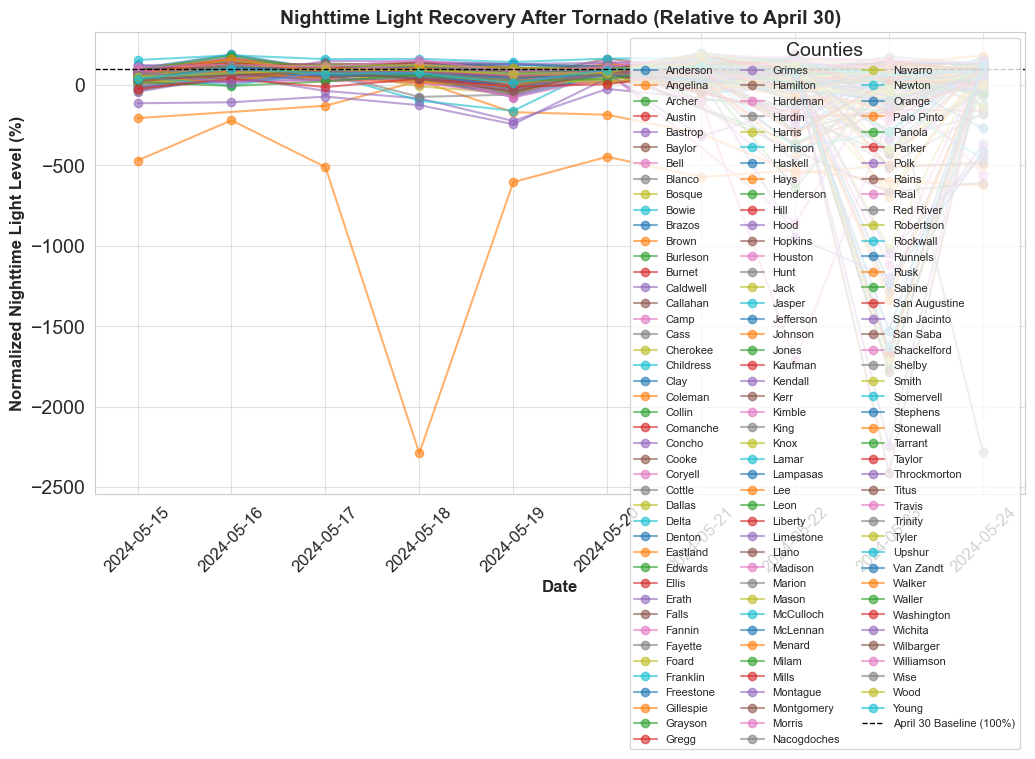

In [6]:
# Import necessary libraries
import os
# Import necessary libraries
import re
# Import necessary libraries
from glob import glob
# Import necessary libraries
import numpy as np
# Import necessary libraries
import pandas as pd
# Import necessary libraries
import geopandas as gpd
# Import necessary libraries
import rasterio
# Import necessary libraries
from rasterstats import zonal_stats
# Import necessary libraries
import matplotlib.pyplot as plt
# Import necessary libraries
import seaborn as sns

# Define file paths
# Define the path to the file or folder using expanduser to support '~'
ntl_folder = os.path.expanduser("~/Downloads/NASA/Work/Texas_Original_Masked_CORRECT")
# Define the path to the file or folder using expanduser to support '~'
shapefile_path = os.path.expanduser("~/Downloads/NASA/Work/CountyMasks/Texas_County_Mask/County.shp")
# Define the path to the file or folder using expanduser to support '~'
output_csv = os.path.expanduser("~/Downloads/NASA/Work/TX_NTL_Percentage_Difference.csv")

# Load the county shapefile into a GeoDataFrame
# Load the shapefile into a GeoDataFrame
counties_gdf = gpd.read_file(shapefile_path)

# Get list of all NTL TIFF files
# Find all files in the folder that match the '*.tif' pattern
ntl_files = sorted(glob(os.path.join(ntl_folder, "*.tif")))

# Ensure the shapefile uses the same CRS as the rasters
if ntl_files:
# Open the raster file to read metadata (like CRS)
    with rasterio.open(ntl_files[0]) as src:
        raster_crs = src.crs
# Convert the CRS of the shapefile to match the raster files
    counties_gdf = counties_gdf.to_crs(raster_crs)

# Identify April 30 Image
apr30_file = None
for ntl_path in ntl_files:
    filename = os.path.basename(ntl_path)
# Extract date from filename using regular expressions
    match = re.search(r"(\d{4})(\d{3})", filename)  # Extract YYYY and Julian day
    if match:
        year, julian_day = match.groups()
# Convert the extracted year and Julian day into a standard date format
        date_str = pd.to_datetime(f"{year}-{julian_day}", format="%Y-%j").strftime("%Y-%m-%d")
        if date_str == "2024-04-30":  # Adjust if using a different year
            apr30_file = ntl_path
            break

if not apr30_file:
    raise FileNotFoundError("April 30 image not found in the dataset!")

# Compute baseline statistics for April 30
# Calculate zonal statistics (mean, median, etc.) over the shapefile zones
apr30_stats = zonal_stats(counties_gdf, apr30_file, stats=["mean", "median"])
apr30_dict = {}

# Store April 30 values in a dictionary, ensuring numerical conversion
for idx in range(len(apr30_stats)):
    county_name = counties_gdf.loc[idx, "CNTY_NM"]
    apr30_mean = pd.to_numeric(apr30_stats[idx].get("mean"), errors="coerce")
    apr30_median = pd.to_numeric(apr30_stats[idx].get("median"), errors="coerce")
    apr30_dict[county_name] = {"mean": apr30_mean, "median": apr30_median}

# Prepare a list to collect results
results = []

# Process May images
for ntl_path in ntl_files:
    filename = os.path.basename(ntl_path)
# Extract date from filename using regular expressions
    match = re.search(r"(\d{4})(\d{3})", filename)
    if match:
        year, julian_day = match.groups()
# Convert the extracted year and Julian day into a standard date format
        date_str = pd.to_datetime(f"{year}-{julian_day}", format="%Y-%j").strftime("%Y-%m-%d")
        
        # Skip if not a May image
        if not date_str.startswith("2024-05"):
            continue
        
        # Compute zonal statistics for this May image
# Calculate zonal statistics (mean, median, etc.) over the shapefile zones
        may_stats = zonal_stats(counties_gdf, ntl_path, stats=["mean", "median"])
        
        # Iterate over each county
        for idx, may_zone in enumerate(may_stats):
            county_name = counties_gdf.loc[idx, "CNTY_NM"]

            # Get April 30 reference values
            apr30_mean = pd.to_numeric(apr30_dict.get(county_name, {}).get("mean"), errors="coerce")
            apr30_median = pd.to_numeric(apr30_dict.get(county_name, {}).get("median"), errors="coerce")

            # Get current May values
            may_mean = pd.to_numeric(may_zone.get("mean"), errors="coerce")
            may_median = pd.to_numeric(may_zone.get("median"), errors="coerce")

            # Skip if any value is missing (NaN)
            if np.isnan(apr30_mean) or np.isnan(may_mean):
                continue

            # Calculate percentage difference safely
            mean_diff_pct = round(((apr30_mean - may_mean) / apr30_mean) * 100, 2) if apr30_mean != 0 else np.nan
            median_diff_pct = round(((apr30_median - may_median) / apr30_median) * 100, 2) if apr30_median != 0 else np.nan
            
            # Append results
# Store the computed statistics and metadata into a list
            results.append({
                "County": county_name,
                "Date": date_str,
                "Mean_NTL_Difference_%": mean_diff_pct,
                "Median_NTL_Difference_%": median_diff_pct
            })

# Convert to DataFrame
# Convert the list of results into a DataFrame
df_results = pd.DataFrame(results)

# **Handle Overlapping Areas: Take Mean for Each County-Date Combination**
df_results = df_results.groupby(["County", "Date"], as_index=False).mean()

# Save to CSV
# Export the DataFrame to a CSV file
df_results.to_csv(output_csv, index=False)

print(f"✅ Overlap-corrected CSV saved to: {output_csv}")

# Load the CSV file for plotting
df = pd.read_csv(output_csv)

# Convert Date column to datetime format for proper plotting
# Convert the extracted year and Julian day into a standard date format
df["Date"] = pd.to_datetime(df["Date"])

# Normalize the data: Convert Mean NTL Difference to a scale where April 30 = 100%
df["Normalized_Light_Level"] = 100 + df["Mean_NTL_Difference_%"]

# Set plot style
sns.set_style("whitegrid")

# Create the plot
plt.figure(figsize=(12, 6))

# Plot trend for each county
for county in df["County"].unique():
    county_df = df[df["County"] == county].sort_values("Date")
    
    # Skip counties where data is missing for key dates
    if county_df["Normalized_Light_Level"].isnull().all():
        continue
    
    plt.plot(county_df["Date"], county_df["Normalized_Light_Level"], marker="o", linestyle="-", label=county, alpha=0.6)

# Add a horizontal line at 100% (April 30 baseline)
plt.axhline(100, color="black", linestyle="--", linewidth=1, label="April 30 Baseline (100%)")

# Titles and labels
plt.title("Nighttime Light Recovery After Tornado (Relative to April 30)", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Normalized Nighttime Light Level (%)", fontsize=12)
plt.xticks(rotation=45)

# Show legend only for key counties to avoid clutter
plt.legend(loc="best", fontsize=8, title="Counties", frameon=True, ncol=3)

# Show the plot
plt.show()



In [3]:
# Import necessary libraries
import os
# Import necessary libraries
import pandas as pd
# Import necessary libraries
import matplotlib.pyplot as plt
# Import necessary libraries
import seaborn as sns

# Load the NTL Percentage Difference CSV
ntl_file_path = "~/Downloads/NASA/Work/TX_NTL_Percentage_Difference.csv"
df_ntl = pd.read_csv(ntl_file_path)

# Load the Cloud Cover CSV (contains "Confident Clear %" values)
cloud_file_path = "~/Downloads/NASA/Work/TX_NTL_Statistics.csv"
df_cloud = pd.read_csv(cloud_file_path)

# Convert "Date" columns to datetime for accurate merging
# Convert the extracted year and Julian day into a standard date format
df_ntl["Date"] = pd.to_datetime(df_ntl["Date"])
# Convert the extracted year and Julian day into a standard date format
df_cloud["Date"] = pd.to_datetime(df_cloud["Date"])

# Merge both datasets on "County" and "Date"
df_merged = pd.merge(df_ntl, df_cloud[["County", "Date", "Confident_Clear_%"]], on=["County", "Date"], how="left")

# Normalize NTL: Convert Mean NTL Difference to a scale where April 30 = 100%
df_merged["Normalized_Light_Level"] = 100 + df_merged["Mean_NTL_Difference_%"]

# Create output folder for high-quality graphs
# Define the path to the file or folder using expanduser to support '~'
output_graphs_folder = os.path.expanduser("~/Downloads/NASA/TX_DIFF_PPT")
os.makedirs(output_graphs_folder, exist_ok=True)

# Set seaborn theme for publication aesthetics
sns.set_style("whitegrid")

# Define global styles for publication-quality plots
plt.rcParams.update({
    "font.size": 14,            # General font size
    "axes.labelsize": 16,       # Labels (X, Y) font size
    "axes.titlesize": 18,       # Title font size
    "legend.fontsize": 14,      # Legend font size
    "xtick.labelsize": 12,      # X-axis tick label size
    "ytick.labelsize": 12,      # Y-axis tick label size
    "axes.grid": True,          # Enable grid
    "grid.alpha": 0.4,          # Grid transparency
    "grid.linestyle": "--",     # Dashed grid lines
    "savefig.dpi": 300          # High-quality DPI for saving figures
})

# Generate and save individual county graphs with publication-level styling
for county in df_merged["County"].unique():
    county_df = df_merged[df_merged["County"] == county].sort_values("Date")
    
    # Skip counties with missing data
    if county_df["Normalized_Light_Level"].isnull().all():
        continue
    
    # Create a high-resolution figure
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot Normalized Light Level (Primary Y-Axis)
    ax1.plot(county_df["Date"], county_df["Normalized_Light_Level"], marker="o", linestyle="-", color="navy", linewidth=2.5, markersize=6, label="Normalized Light Level (%)")
    ax1.set_ylabel("Normalized Light Level (%)", fontsize=16, color="navy")
    ax1.tick_params(axis="y", labelcolor="navy")
    ax1.set_ylim(0, 150)  # Fixed Y-axis range for all graphs

    # Add a horizontal line at 100% (April 30 baseline) for reference
    ax1.axhline(100, color="black", linestyle="--", linewidth=1.5, label="April 30 Baseline (100%)")

    # Add secondary Y-axis for Confident Clear %
    ax2 = ax1.twinx()
    ax2.plot(county_df["Date"], county_df["Confident_Clear_%"], marker="s", linestyle="--", color="darkgreen", linewidth=2, markersize=6, label="Confident Clear (%)")
    ax2.set_ylabel("Confident Clear (%)", fontsize=16, color="darkgreen")
    ax2.tick_params(axis="y", labelcolor="darkgreen")
    ax2.set_ylim(0, 100)  # Fixed Y-axis range for all graphs

    # Titles and labels
    plt.title(f"Nighttime Light Recovery & Cloud Cover - {county}", fontsize=18, fontweight="bold")

    # ✅ Fix: Move X-axis title downward to avoid overlap
    ax1.set_xlabel("Date (YYYY-MM-DD)", fontsize=16, labelpad=20)
    ax1.xaxis.set_label_coords(0.5, -0.15)  # Moves label downward

    # Tilt X-axis labels slightly for clarity
    plt.xticks(rotation=30, ha="right")
    plt.gcf().autofmt_xdate()
    
    # ✅ Fix: Add more space below for X-axis title
    plt.subplots_adjust(bottom=0.25)

    # Combine Legends and move to Upper Left to avoid overlap
    #lines1, labels1 = ax1.get_legend_handles_labels()
    #lines2, labels2 = ax2.get_legend_handles_labels()
    #ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right", fontsize=14, frameon=True, borderpad=1, edgecolor="black")

    # Improve spacing for readability
    plt.tight_layout()

    # Save the figure in high resolution
    graph_path = os.path.join(output_graphs_folder, f"{county}_NTL_Recovery_Publication.png")
    plt.savefig(graph_path, bbox_inches="tight", dpi=300)

    # Close the plot to free memory
    plt.close()

print(f"✅ All publication-quality county graphs saved in: {output_graphs_folder}")


✅ All publication-quality county graphs saved in: /Users/ba924/Downloads/NASA/TX_DIFF_PPT
